# Random Forest

## Importación de librerías y paquetes y definición de constantes

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# To save models
import json
import pickle
# Modelado
from xgboost import XGBClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
# Métricas
from sklearn.metrics import confusion_matrix
from utils import get_classifier_metrics
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV, cross_val_score
# Warnings
import warnings

In [51]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Vamos a probar tres enfoques diferentes para la generación de este modelo:

1. Dataset truncado
2. Dataset con valores nulos remplazados por la moda
3. Dataset con valores nulos remplazados por los k-nearest neighbors


## 1. Dataset truncado:

### Cargamos el dataset procedente del eda previo

In [52]:
df_filtrado = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/df_diabetes_filtrado.csv")
df_filtrado

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,89,66,23,94,28.1,0.167,21,0
1,0,137,40,35,168,43.1,2.288,33,1
2,3,78,50,32,88,31.0,0.248,26,1
3,2,197,70,45,543,30.5,0.158,53,1
4,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
388,0,181,88,44,510,43.3,0.222,26,1
389,1,128,88,39,110,36.5,1.057,37,1
390,2,88,58,26,16,28.4,0.766,22,0
391,10,101,76,48,180,32.9,0.171,63,0


### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable Outcome' como target

In [53]:
# Instancia de: from sklearn.model_selection import train_test_split
X_train_filtrado, X_test_filtrado, y_train_filtrado, y_test_filtrado = train_test_split(df_filtrado.drop('Outcome', axis=1), 
                                                                                        df_filtrado['Outcome'],
                                                                                        test_size=0.2,
                                                                                        random_state=24,
                                                                                        stratify=df_filtrado['Outcome'])
X_train_filtrado

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
282,5,187,76,27,207,43.6,1.034,53
39,7,81,78,40,48,46.7,0.261,42
295,4,154,72,29,126,31.3,0.338,37
341,3,80,82,31,70,34.2,1.292,27
51,8,155,62,26,495,34.0,0.543,46
...,...,...,...,...,...,...,...,...
364,2,93,64,32,160,38.0,0.674,23
265,9,145,88,34,165,30.3,0.771,53
232,0,91,68,32,210,39.9,0.381,25
315,3,106,54,21,158,30.9,0.292,24


### Modelado y Ajuste

In [54]:
xg_classifier_model_filtrado = XGBClassifier(random_state = 24)
xg_classifier_model_filtrado.fit(X_train_filtrado, y_train_filtrado)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Predicción 

In [55]:
y_pred_test_fil = xg_classifier_model_filtrado.predict(X_test_filtrado)
y_pred_test_fil

array([0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0])

In [56]:
y_pred_train_fil = xg_classifier_model_filtrado.predict(X_train_filtrado)
y_pred_train_fil

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,

#### Matriz de confusión

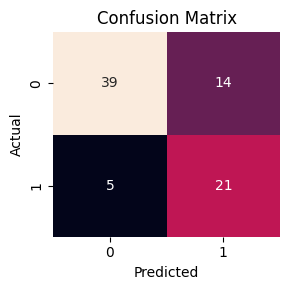

In [57]:
diabetes_cm = confusion_matrix(y_test_filtrado, y_pred_test_fil)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [58]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.759494,0.759494,0.759494,0.759494


In [59]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.759494,0.746324,0.743182,0.771771


In [60]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.759494,0.766078,0.792117,0.759494


## 2. Dataset con valores nulos remplazados por la moda

In [61]:
df_mode = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/df_diabetes_mode.csv")
df_mode

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,105.0,33.6,0.627,50,1
1,1,85,66,29.0,105.0,26.6,0.351,31,0
2,8,183,64,32.0,105.0,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.0,180.0,32.9,0.171,63,0
764,2,122,70,27.0,105.0,36.8,0.340,27,0
765,5,121,72,23.0,112.0,26.2,0.245,30,0
766,1,126,60,32.0,105.0,30.1,0.349,47,1


### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable Outcome' como target

In [62]:
# Instancia de: from sklearn.model_selection import train_test_split
X_train_mode, X_test_mode, y_train_mode, y_test_mode = train_test_split(df_mode.drop('Outcome', axis=1), 
                                                                        df_mode['Outcome'],
                                                                        test_size=0.2,
                                                                        random_state=24,
                                                                        stratify=df_mode['Outcome'])
X_train_mode

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
712,10,129,62,36.0,105.0,41.2,0.441,38
626,0,125,68,32.0,105.0,24.7,0.206,21
157,1,109,56,21.0,135.0,25.2,0.833,23
401,6,137,61,32.0,105.0,24.2,0.151,55
355,9,165,88,32.0,105.0,30.4,0.302,49
...,...,...,...,...,...,...,...,...
381,0,105,68,22.0,105.0,20.0,0.236,22
324,2,112,75,32.0,105.0,35.7,0.148,21
68,1,95,66,13.0,38.0,19.6,0.334,25
704,4,110,76,20.0,100.0,28.4,0.118,27


### Modelado y Ajuste

In [63]:
xg_classifier_model_mode = XGBClassifier(random_state = 24)
xg_classifier_model_mode.fit(X_train_mode, y_train_mode)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Predicción 

In [64]:
y_pred_test_mode = xg_classifier_model_mode.predict(X_test_mode)
y_pred_test_mode

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [65]:
y_pred_train_mode = xg_classifier_model_mode.predict(X_train_mode)
y_pred_train_mode

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,

#### Matriz de confusión

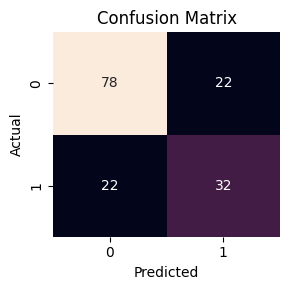

In [66]:
diabetes_cm = confusion_matrix(y_test_mode, y_pred_test_mode)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [67]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.714286,0.714286,0.714286


In [68]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.686296,0.686296,0.686296


In [69]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.714286,0.714286,0.714286


## 3. Dataset con valores nulos remplazados por los k-nearest neighbors

In [70]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/df_diabetes_kn.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.00000,232.600000,33.6,0.627,50,1
1,1,85,66,29.00000,184.800000,26.6,0.351,31,0
2,8,183,64,29.15342,155.548223,23.3,0.672,32,1
3,1,89,66,23.00000,94.000000,28.1,0.167,21,0
4,0,137,40,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.00000,180.000000,32.9,0.171,63,0
764,2,122,70,27.00000,155.400000,36.8,0.340,27,0
765,5,121,72,23.00000,112.000000,26.2,0.245,30,0
766,1,126,60,29.15342,155.548223,30.1,0.349,47,1


### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable Outcome' como target

In [71]:
# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis=1), 
                                                    df['Outcome'],
                                                    test_size=0.2,
                                                    random_state=24,
                                                    stratify=df['Outcome'])
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
712,10,129,62,36.00000,199.400000,41.2,0.441,38
626,0,125,68,29.15342,155.548223,24.7,0.206,21
157,1,109,56,21.00000,135.000000,25.2,0.833,23
401,6,137,61,29.15342,155.548223,24.2,0.151,55
355,9,165,88,29.15342,155.548223,30.4,0.302,49
...,...,...,...,...,...,...,...,...
381,0,105,68,22.00000,107.200000,20.0,0.236,22
324,2,112,75,32.00000,152.600000,35.7,0.148,21
68,1,95,66,13.00000,38.000000,19.6,0.334,25
704,4,110,76,20.00000,100.000000,28.4,0.118,27


### Modelado y Ajuste

In [72]:
xg_classifier_model = XGBClassifier(random_state = 24)
xg_classifier_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Predicción 

In [73]:
y_pred_test = xg_classifier_model.predict(X_test)
y_pred_test

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [74]:
y_pred_train = xg_classifier_model.predict(X_train)
y_pred_train

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,

#### Matriz de confusión

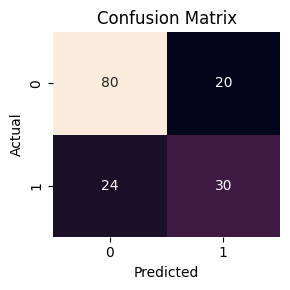

In [75]:
diabetes_cm = confusion_matrix(y_test, y_pred_test)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [76]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.714286,0.714286,0.714286


In [77]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.680618,0.684615,0.677778


In [78]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.00000,1.000000
Test set,0.714286,0.711592,0.70989,0.714286


## Conclusiones:

>- Después de varias pruebas, a profundidad máxima observamos que el modelo sufre overfitting (las métricas de train son perfectas)
>- El modelo mejora en el caso de los KNN respecto al del dataset con valores eliminados
>- Sin embargo no hay una mejora significativa con este modelo respecto al caso anterior de decision tree
>- Procedemos a la búsqueda de los mejores parámetros

## Buscamos los mejores parámetros con `GridSearchCV`

### Definición de parámetros y métricas

In [80]:
param_grid = {'n_estimators': [100, 200, 300],
              'max_depth': [3, 5, 7, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],
              'max_features': ['sqrt', 'log2', None]
}
grid_search = GridSearchCV(estimator=xg_classifier_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1
)


#### Entrenamiento de la cuadrícula

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,RandomForestC...ndom_state=24)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


#### Mejores parámetros

In [ ]:
grid_search.best_estimator_

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
grid_search.best_params_

{'max_depth': None,
 'max_features': None,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 200}

#### Reentrenamos al modelo con los nuevos parámetros:

In [ ]:
dt_classifier_model_grid = RandomForestClassifier(n_estimators=50, min_samples_split=10, min_samples_leaf=2, random_state=24)
dt_classifier_model_grid.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Predicción 

In [ ]:
best_model = grid_search.best_estimator_
y_pred_test = dt_classifier_model_grid.predict(X_test)
y_pred_test

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [ ]:
y_pred_train = dt_classifier_model_grid.predict(X_train)
y_pred_train

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,

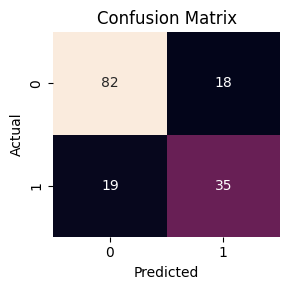

In [ ]:
diabetes_cm = confusion_matrix(y_test, y_pred_test)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [ ]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.942997,0.942997,0.942997,0.942997
Test set,0.759740,0.759740,0.759740,0.759740


In [ ]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.942997,0.936306,0.943581,0.930175
Test set,0.759740,0.735063,0.736129,0.734074


In [ ]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.942997,0.942560,0.943068,0.942997
Test set,0.759740,0.759215,0.758756,0.759740


## Conclusiones:

>- Utilizando un modelo de random forest, el resultado mejora un pequeño porcentaje. No me parece significativa la mejora para el coste computacional que implica.
>- Por ahora el mejor resultado lo consigo con `n_stimators` en 50
>- Creo que podemos concluir que la calidad de los datos no son "suficientes" para generar un modelo robuzto y eficiente que sea capaz de predecir con más precisión

## Añadimos un cuarto enfoque dejando el dataset sin tratar los valores nulos, ya que el boosting con xgboost contempla estos casos

In [ ]:
df_null = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/diabetes.csv")


In [ ]:
df_null.loc[df_null['Insulin'] <= 0, 'Insulin'] = np.nan
df_null.loc[df_null['SkinThickness'] <= 0, 'SkinThickness'] = np.nan
df_null.loc[df_null['BloodPressure'] <= 0, 'BloodPressure'] = np.nan

In [ ]:
df_null.isnull().sum().sort_values(ascending=False) / len(df)

Insulin                     0.486979
SkinThickness               0.295573
BloodPressure               0.045573
Pregnancies                 0.000000
Glucose                     0.000000
BMI                         0.000000
DiabetesPedigreeFunction    0.000000
Age                         0.000000
Outcome                     0.000000
dtype: float64

In [ ]:
# Instancia de: from sklearn.model_selection import train_test_split
X_train_null, X_test_null, y_train_null, y_test_null = train_test_split(df_null.drop('Outcome', axis=1), 
                                                    df_null['Outcome'],
                                                    test_size=0.2,
                                                    random_state=24,
                                                    stratify=df['Outcome'])
X_train_null

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
712,10,129,62.0,36.0,NaN,41.2,0.441,38
626,0,125,68.0,NaN,NaN,24.7,0.206,21
157,1,109,56.0,21.0,135.0,25.2,0.833,23
401,6,137,61.0,NaN,NaN,24.2,0.151,55
355,9,165,88.0,NaN,NaN,30.4,0.302,49
...,...,...,...,...,...,...,...,...
381,0,105,68.0,22.0,NaN,20.0,0.236,22
324,2,112,75.0,32.0,NaN,35.7,0.148,21
68,1,95,66.0,13.0,38.0,19.6,0.334,25
704,4,110,76.0,20.0,100.0,28.4,0.118,27


In [ ]:
# rf_classifier_model = RandomForestClassifier(random_state = 24)
xg_classifier_model.fit(X_train_null, y_train_null)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred_test_null = xg_classifier_model.predict(X_test_null)
y_pred_test_null

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0])

In [ ]:
y_pred_train_null = xg_classifier_model.predict(X_train_null)
y_pred_train_null

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,

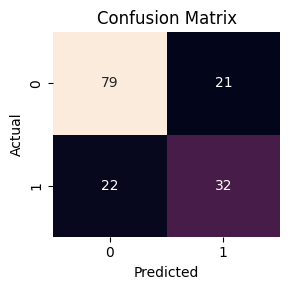

In [ ]:
diabetes_cm = confusion_matrix(y_test_null, y_pred_test_null)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
get_classifier_metrics(y_pred_test_null, y_test_null, y_pred_train_null, y_train_null) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.720779,0.720779,0.720779,0.720779


In [ ]:
get_classifier_metrics(y_pred_test_null, y_test_null, y_pred_train_null, y_train_null, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.0000,1.000000,1.000000
Test set,0.720779,0.6921,0.692976,0.691296


In [ ]:
get_classifier_metrics(y_pred_test_null, y_test_null, y_pred_train_null, y_train_null, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.720779,0.720169,0.719621,0.720779
